In [1]:
from typing import Union
import matplotlib.pyplot as plt

def parse_listing(text: str):
    lines = text.split('\n')
    ret: list[float] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<item>') and line.endswith('</item>')
        ret.append(float(line[6:-7].strip()))
    return ret
def parse_oplus_level_listing(text: str):
    lines = text.split('\n')
    ret: list[list[float]] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<level>') and line.endswith('</level>')
        ret.append([float(t) for t in line[7:-8].strip().split(',')])
    return ret
def make_listing(values: list[Union[int, float]]):
    ret = ''
    for value in values:
        ret += f'<item>{value}</item>\n'
    return ret

In [2]:
def list_to_list_linear_map(val: float, src: list[float], dst: list[float]):
    assert len(src) == len(dst)
    for i in range(len(src) - 1):
        assert src[i] <= src[i + 1]
    for i in range(len(src) - 1):
        if src[i] <= val <= src[i + 1]:
            break
    else:
        raise ValueError('Value out of range.')
    ratio = (val - src[i]) / (src[i + 1] - src[i])
    return dst[i] + (dst[i + 1] - dst[i]) * ratio

In [3]:
oos_brightness_profile = parse_oplus_level_listing(open('./cos_brightness_profile.txt', 'r').read())
los_backlight = parse_listing('''
    <item>0</item>
    <item>4</item>
    <item>8</item>
    <item>12</item>
    <item>16</item>
    <item>20</item>
    <item>24</item>
    <item>28</item>
    <item>32</item>
    <item>36</item>
    <item>40</item>
    <item>44</item>
    <item>48</item>
    <item>52</item>
    <item>56</item>
    <item>60</item>
    <item>64</item>
    <item>68</item>
    <item>72</item>
    <item>76</item>
    <item>80</item>
    <item>84</item>
    <item>88</item>
    <item>92</item>
    <item>96</item>
    <item>100</item>
    <item>104</item>
    <item>108</item>
    <item>112</item>
    <item>116</item>
    <item>120</item>
    <item>123</item>
    <item>127</item>
    <item>131</item>
    <item>135</item>
    <item>139</item>
    <item>143</item>
    <item>147</item>
    <item>151</item>
    <item>155</item>
    <item>159</item>
    <item>163</item>
    <item>167</item>
    <item>171</item>
    <item>175</item>
    <item>179</item>
    <item>183</item>
    <item>187</item>
    <item>191</item>
    <item>195</item>
    <item>199</item>
    <item>203</item>
    <item>207</item>
    <item>211</item>
    <item>215</item>
    <item>219</item>
    <item>223</item>
    <item>227</item>
    <item>231</item>
    <item>235</item>
    <item>239</item>
    <item>243</item>
    <item>246</item>
    <item>251</item>
    <item>255</item>
''')
los_nits = parse_listing('''
    <item>0.0</item>
    <item>2.1</item>
    <item>2.31</item>
    <item>2.63</item>
    <item>3.16</item>
    <item>3.73</item>
    <item>4.42</item>
    <item>5.45</item>
    <item>6.69</item>
    <item>8.07</item>
    <item>9.65</item>
    <item>11.32</item>
    <item>13.26</item>
    <item>15.59</item>
    <item>18.14</item>
    <item>20.68</item>
    <item>23.58</item>
    <item>26.38</item>
    <item>29.67</item>
    <item>32.83</item>
    <item>36.03</item>
    <item>39.31</item>
    <item>43.8</item>
    <item>47.95</item>
    <item>52.08</item>
    <item>56.86</item>
    <item>61.83</item>
    <item>67.93</item>
    <item>73.37</item>
    <item>79.96</item>
    <item>86.15</item>
    <item>90.75</item>
    <item>97.83</item>
    <item>105.67</item>
    <item>112.79</item>
    <item>120.33</item>
    <item>127.82</item>
    <item>135.71</item>
    <item>145.0</item>
    <item>153.32</item>
    <item>161.78</item>
    <item>170.61</item>
    <item>179.7</item>
    <item>190.25</item>
    <item>201.81</item>
    <item>212.07</item>
    <item>222.79</item>
    <item>234.01</item>
    <item>246.43</item>
    <item>257.49</item>
    <item>269.8</item>
    <item>281.41</item>
    <item>293.94</item>
    <item>307.58</item>
    <item>322.53</item>
    <item>335.82</item>
    <item>349.68</item>
    <item>364.86</item>
    <item>379.57</item>
    <item>398.55</item>
    <item>413.85</item>
    <item>429.97</item>
    <item>442.89</item>
    <item>461.76</item>
    <item>478.65</item>
''')
los_auto_lux = parse_listing('''
    <item>1</item>
    <item>4</item>
    <item>12</item>
    <item>20</item>
    <item>28</item>
    <item>47</item>
    <item>63</item>
    <item>86</item>
    <item>150</item>
    <item>160</item>
    <item>220</item>
    <item>270</item>
    <item>360</item>
    <item>420</item>
    <item>510</item>
    <item>620</item>
    <item>1000</item>
    <item>2000</item>
    <item>3100</item>
    <item>5000</item>
    <item>8000</item>
    <item>12000</item>
    <item>16000</item>
    <item>20000</item>
''')
los_auto_nits = parse_listing('''
    <item>2.0487</item>
    <item>4.8394</item>
    <item>15.2619</item>
    <item>30.2619</item>
    <item>46.671</item>
    <item>65.95</item>
    <item>80.46</item>
    <item>84.38</item>
    <item>89.51</item>
    <item>100.34</item>
    <item>102.21</item>
    <item>109.48</item>
    <item>114.19</item>
    <item>123.86</item>
    <item>129.18</item>
    <item>138.07</item>
    <item>145.62</item>
    <item>168.84</item>
    <item>234.9</item>
    <item>280</item>
    <item>320</item>
    <item>360</item>
    <item>405</item>
    <item>450</item>
    <item>500</item>
''')
crd_backlight = parse_listing('''
    <item>1</item>
    <item>255</item>
''')
crd_nits = parse_listing('''
    <item>1</item>
    <item>1100</item>
''')
crd_auto_lux = parse_listing('''
    <item>1</item>
    <item>4</item>
    <item>12</item>
    <item>20</item>
    <item>28</item>
    <item>47</item>
    <item>63</item>
    <item>86</item>
    <item>150</item>
    <item>220</item>
    <item>270</item>
    <item>360</item>
    <item>420</item>
    <item>510</item>
    <item>620</item>
    <item>1000</item>
    <item>2000</item>
    <item>3100</item>
    <item>3988</item>
    <item>5018</item>
    <item>6232</item>
    <item>7648</item>
    <item>9280</item>
    <item>11146</item>
    <item>13261</item>
    <item>15640</item>
    <item>18302</item>
    <item>21260</item>
    <item>24532</item>
    <item>28133</item>
    <item>32080</item>
    <item>36388</item>
    <item>41073</item>
    <item>46153</item>
    <item>51642</item>
    <item>63912</item>
    <item>78015</item>
    <item>94076</item>
    <item>112226</item>
    <item>132592</item>
    <item>155302</item>
    <item>180486</item>
    <item>208271</item>
    <item>223180</item>
    <item>255108</item>
''')
crd_auto_nits = parse_listing('''
    <item>2.0487</item>
    <item>4.8394</item>
    <item>15.2619</item>
    <item>33</item>
    <item>49</item>
    <item>62.95</item>
    <item>76.46</item>
    <item>84.38</item>
    <item>89.51</item>
    <item>100.34</item>
    <item>109.48</item>
    <item>115</item>
    <item>117.67</item>
    <item>122.72</item>
    <item>131.17</item>
    <item>141.19</item>
    <item>167.05</item>
    <item>234.9</item>
    <item>279</item>
    <item>300</item>
    <item>320</item>
    <item>340</item>
    <item>360</item>
    <item>380</item>
    <item>400</item>
    <item>420</item>
    <item>440</item>
    <item>460</item>
    <item>480</item>
    <item>500</item>
    <item>520</item>
    <item>540</item>
    <item>560</item>
    <item>580</item>
    <item>600</item>
    <item>620</item>
    <item>660</item>
    <item>700</item>
    <item>740</item>
    <item>780</item>
    <item>820</item>
    <item>860</item>
    <item>900</item>
    <item>940</item>
    <item>1000</item>
    <item>1100</item>
''')
oos_ui_sustainable_max = 8191
oos_register_sustainable_max = 2047
oos_ui = [ 1 + item[0] / oos_ui_sustainable_max * 254 for item in oos_brightness_profile ]
oos_register = [ 1 + item[1] / oos_register_sustainable_max * 254 for item in oos_brightness_profile ]
oos_nits = [ item[2] for item in oos_brightness_profile ]


## Explore OxygenOS brightness profile

0.0
486.74194
796.55792


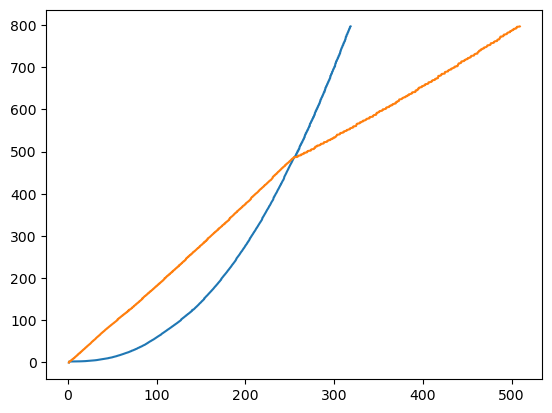

In [4]:
plt.plot(oos_ui, oos_nits)
plt.plot(oos_register, oos_nits)
print(list_to_list_linear_map(1, oos_register, oos_nits))
print(list_to_list_linear_map(255, oos_register, oos_nits))
print(list_to_list_linear_map(509, oos_register, oos_nits))

Now re-generate backlight to nits mapping for LineageOS using the register to nits mapping.

In [5]:
los_corrected_backlight = [1, 2, 4] + list(range(5, 512, 4))
print(make_listing(los_corrected_backlight))

<item>1</item>
<item>2</item>
<item>4</item>
<item>5</item>
<item>9</item>
<item>13</item>
<item>17</item>
<item>21</item>
<item>25</item>
<item>29</item>
<item>33</item>
<item>37</item>
<item>41</item>
<item>45</item>
<item>49</item>
<item>53</item>
<item>57</item>
<item>61</item>
<item>65</item>
<item>69</item>
<item>73</item>
<item>77</item>
<item>81</item>
<item>85</item>
<item>89</item>
<item>93</item>
<item>97</item>
<item>101</item>
<item>105</item>
<item>109</item>
<item>113</item>
<item>117</item>
<item>121</item>
<item>125</item>
<item>129</item>
<item>133</item>
<item>137</item>
<item>141</item>
<item>145</item>
<item>149</item>
<item>153</item>
<item>157</item>
<item>161</item>
<item>165</item>
<item>169</item>
<item>173</item>
<item>177</item>
<item>181</item>
<item>185</item>
<item>189</item>
<item>193</item>
<item>197</item>
<item>201</item>
<item>205</item>
<item>209</item>
<item>213</item>
<item>217</item>
<item>221</item>
<item>225</item>
<item>229</item>
<item>233</i

In [6]:
los_corrected_nits = [ list_to_list_linear_map(item, oos_register, oos_nits) for item in los_corrected_backlight ]
print(make_listing(los_corrected_nits))

<item>0.0</item>
<item>2.2439639173228345</item>
<item>5.4837140535433075</item>
<item>7.334082871653544</item>
<item>14.4697758503937</item>
<item>22.159102062992126</item>
<item>29.474306661417323</item>
<item>37.1207317007874</item>
<item>44.470513377952756</item>
<item>52.425334645669295</item>
<item>60.21113661417323</item>
<item>68.14474003149606</item>
<item>75.20726877165355</item>
<item>82.49232967716536</item>
<item>89.3842351496063</item>
<item>96.02842907874016</item>
<item>104.07948078740158</item>
<item>110.77960881889764</item>
<item>117.18521070866142</item>
<item>124.9346457480315</item>
<item>131.04354417322836</item>
<item>138.4253638582677</item>
<item>145.80851598425195</item>
<item>154.0610407086614</item>
<item>161.51214952755905</item>
<item>168.88531070866142</item>
<item>175.83058039370079</item>
<item>183.51730874015746</item>
<item>190.92452566929134</item>
<item>199.57301362204726</item>
<item>206.65671874015746</item>
<item>214.18523275590553</item>
<item>

## Explore existing lux to nits mappings

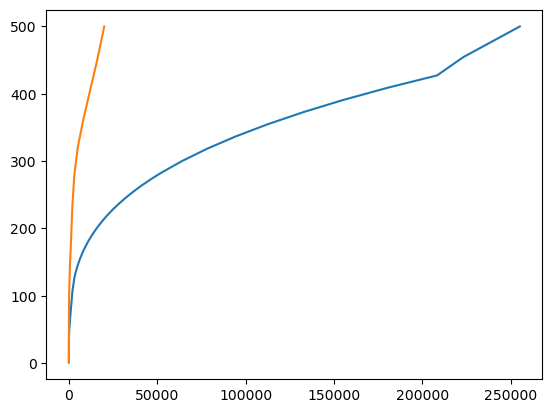

In [7]:
plt.plot([0, *crd_auto_lux], [item / 1100 * 500 for item in crd_auto_nits])
plt.plot([0, *[item for item in los_auto_lux]], los_auto_nits)

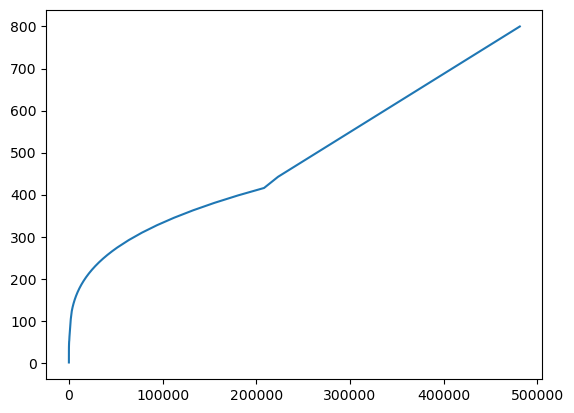

In [8]:
los_corrected_auto_lux = crd_auto_lux
max_sustainable_nits = list_to_list_linear_map(255, oos_register, oos_nits)
los_corrected_auto_nits = [item / 1100 * max_sustainable_nits for item in crd_auto_nits]

# Extrapolate to 
# los_corrected_auto_lux = los_corrected_auto_lux[:-1]
# los_corrected_auto_nits = los_corrected_auto_nits[:-1]
point = (los_corrected_auto_lux[-1], los_corrected_auto_nits[-1])
slope = (
    los_corrected_auto_nits[-1] - los_corrected_auto_nits[-2]
) / (
    los_corrected_auto_lux[-1] - los_corrected_auto_lux[-2]
)

for extended_nit in [ 500, 550, 600, 800 ]:
    los_corrected_auto_nits.append(extended_nit)
    los_corrected_auto_lux.append(
        point[0] + (los_corrected_auto_nits[-1] - point[1]) / slope
    )

plt.plot([0, *los_corrected_auto_lux], los_corrected_auto_nits)

In [9]:
print(make_listing([int(item) for item in los_corrected_auto_lux]))

<item>1</item>
<item>4</item>
<item>12</item>
<item>20</item>
<item>28</item>
<item>47</item>
<item>63</item>
<item>86</item>
<item>150</item>
<item>220</item>
<item>270</item>
<item>360</item>
<item>420</item>
<item>510</item>
<item>620</item>
<item>1000</item>
<item>2000</item>
<item>3100</item>
<item>3988</item>
<item>5018</item>
<item>6232</item>
<item>7648</item>
<item>9280</item>
<item>11146</item>
<item>13261</item>
<item>15640</item>
<item>18302</item>
<item>21260</item>
<item>24532</item>
<item>28133</item>
<item>32080</item>
<item>36388</item>
<item>41073</item>
<item>46153</item>
<item>51642</item>
<item>63912</item>
<item>78015</item>
<item>94076</item>
<item>112226</item>
<item>132592</item>
<item>155302</item>
<item>180486</item>
<item>208271</item>
<item>223180</item>
<item>255108</item>
<item>264674</item>
<item>300751</item>
<item>336829</item>
<item>481138</item>



In [10]:
print(make_listing(los_corrected_auto_nits))

<item>0.9065347386163637</item>
<item>2.141399040396364</item>
<item>6.753278921896364</item>
<item>14.6022582</item>
<item>21.682140963636364</item>
<item>27.85491374818182</item>
<item>33.83298975672727</item>
<item>37.33753172472727</item>
<item>39.60751913581819</item>
<item>44.39971478145455</item>
<item>48.444097810181816</item>
<item>50.88665736363636</item>
<item>52.06811279981818</item>
<item>54.30270079709091</item>
<item>58.041763881636356</item>
<item>62.47554046236363</item>
<item>73.9184009790909</item>
<item>103.94152882363636</item>
<item>123.4554556909091</item>
<item>132.7478018181818</item>
<item>141.59765527272725</item>
<item>150.44750872727272</item>
<item>159.2973621818182</item>
<item>168.14721563636363</item>
<item>176.9970690909091</item>
<item>185.84692254545456</item>
<item>194.696776</item>
<item>203.54662945454544</item>
<item>212.3964829090909</item>
<item>221.24633636363635</item>
<item>230.0961898181818</item>
<item>238.94604327272728</item>
<item>247.7